In [1]:
!pip install scanpy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 1.4 MB/s eta 0:00:02
   ------------------- -------------------- 1.0/2.1 MB 1.5 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.7 MB/s  0:00:01
   ---------------------------------------- 0.0/799.3 kB ? eta -:--:--
   -------------------------- ------------- 524.3/799.3 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 799.3/799.3 kB 2.5 MB/s  0:00:00

   --- ------------------------------------  1/13 [numcodecs]
   --- ------------------------------------  1/13 [numcodecs]
   --------------- ------------------------  5/13 [fast-array-u

In [2]:
import scanpy as sc
print(sc.__version__)

1.12


C:\Users\ajibo\AppData\Local\Temp\ipykernel_14240\289967954.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [3]:
pwd

'C:\\Users\\ajibo'

In [4]:
import scanpy as sc

adata = sc.read_10x_mtx(
    r"C:\Users\ajibo\OneDrive\Desktop\hg19",
    var_names="gene_symbols",
    cache=True
)

adata.var_names_make_unique()

In [7]:
!pip install leidenalg

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 10.2 MB/s  0:00:00
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------  3.1/3.2 MB 20.1 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 18.3 MB/s  0:00:00

   ------------- -------------------------- 1/3 [igraph]
   ------------- -------------------------- 1/3 [igraph]
   ------------- -------------------------- 1/3 [igraph]
   ---------------------------------------- 3/3 [leidenalg]



In [8]:
adata

AnnData object with n_obs × n_vars = 2700 × 1738
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

C:\Users\ajibo\anaconda3\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
C:\Users\ajibo\AppData\Local\Temp\ipykernel_14240\2824462425.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


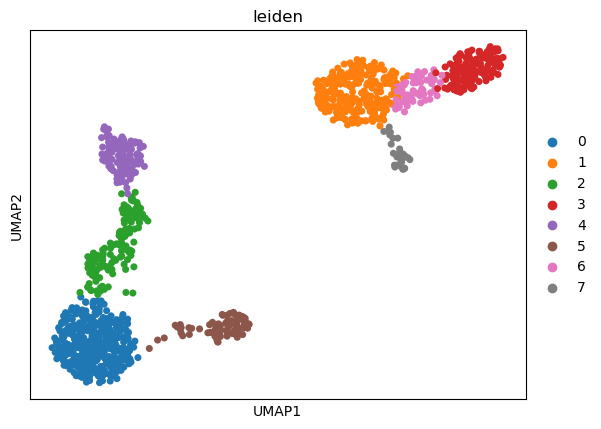

In [9]:
# QC
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable]

# PCA
sc.tl.pca(adata)

# Clustering
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

# UMAP
sc.tl.umap(adata)

# Plot
sc.pl.umap(adata, color=["leiden"])

In [10]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")

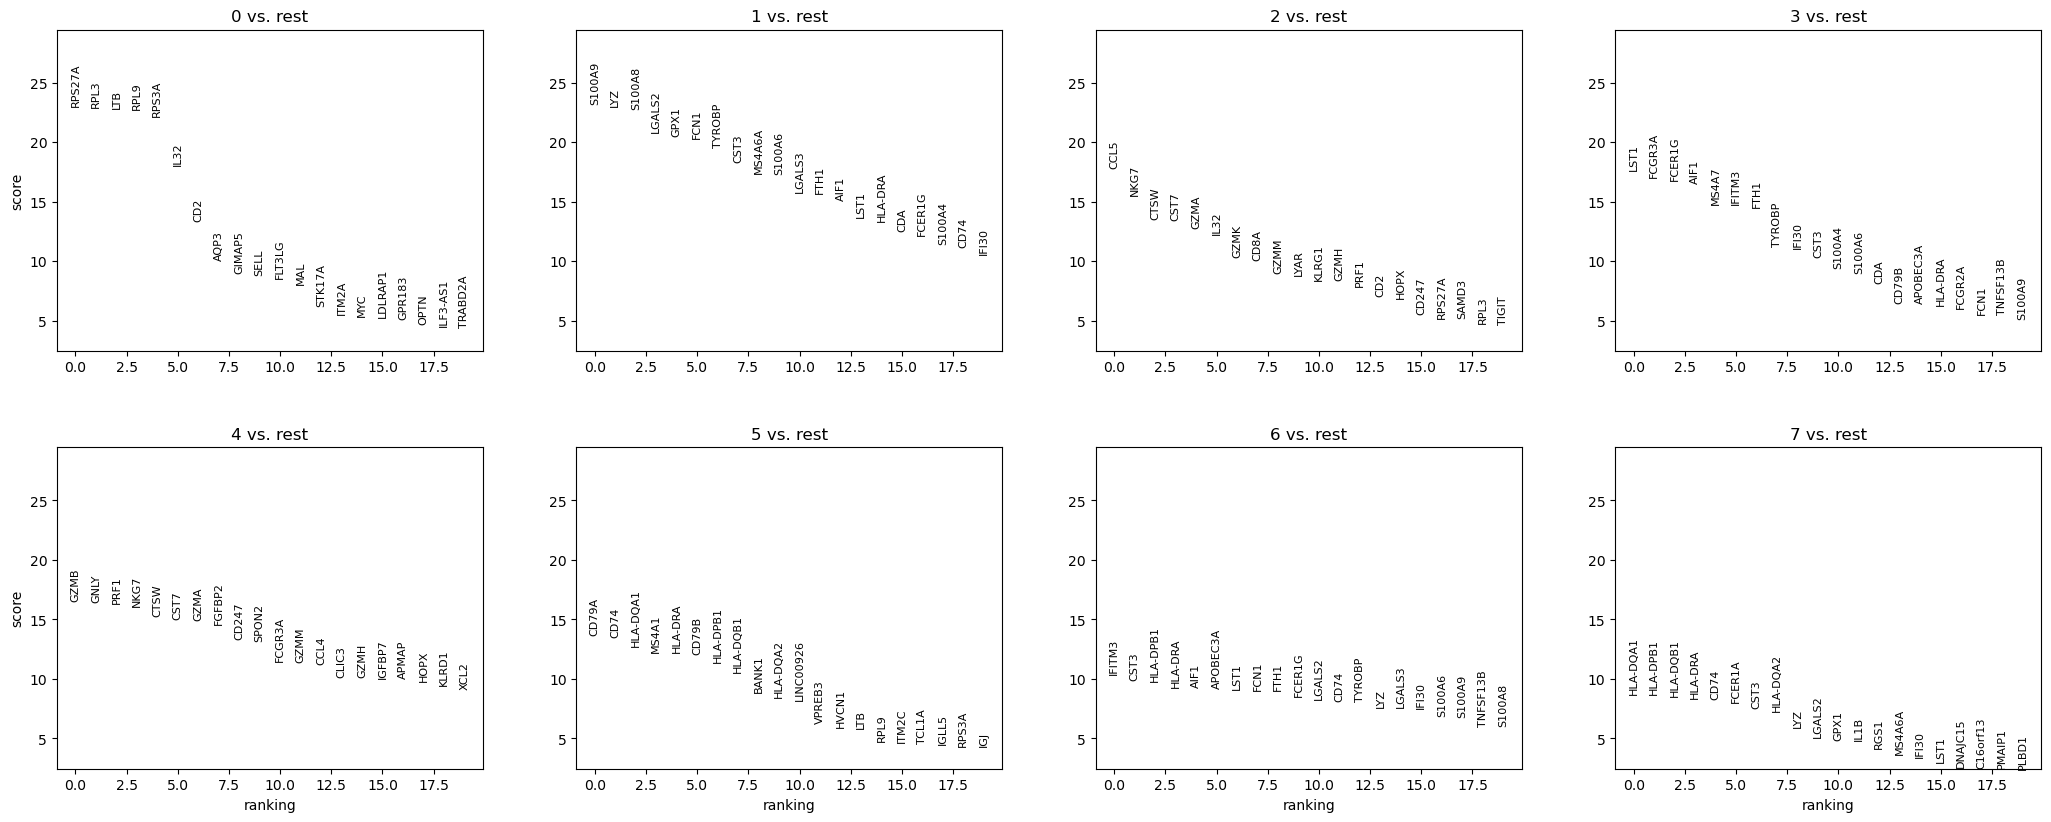

In [11]:
sc.pl.rank_genes_groups(adata, n_genes=20)

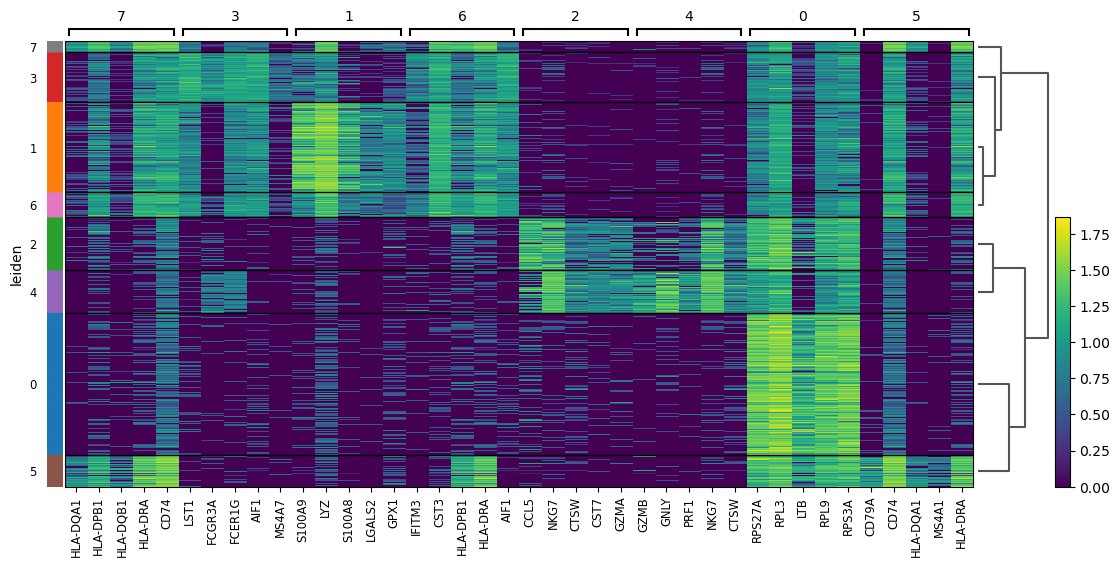

In [19]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby="leiden")

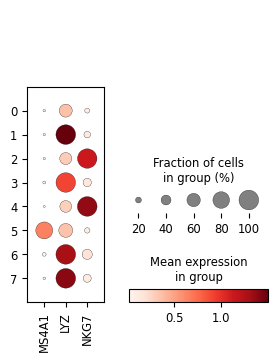

In [21]:
sc.pl.dotplot(adata, var_names=["MS4A1","LYZ","NKG7"], groupby="leiden")

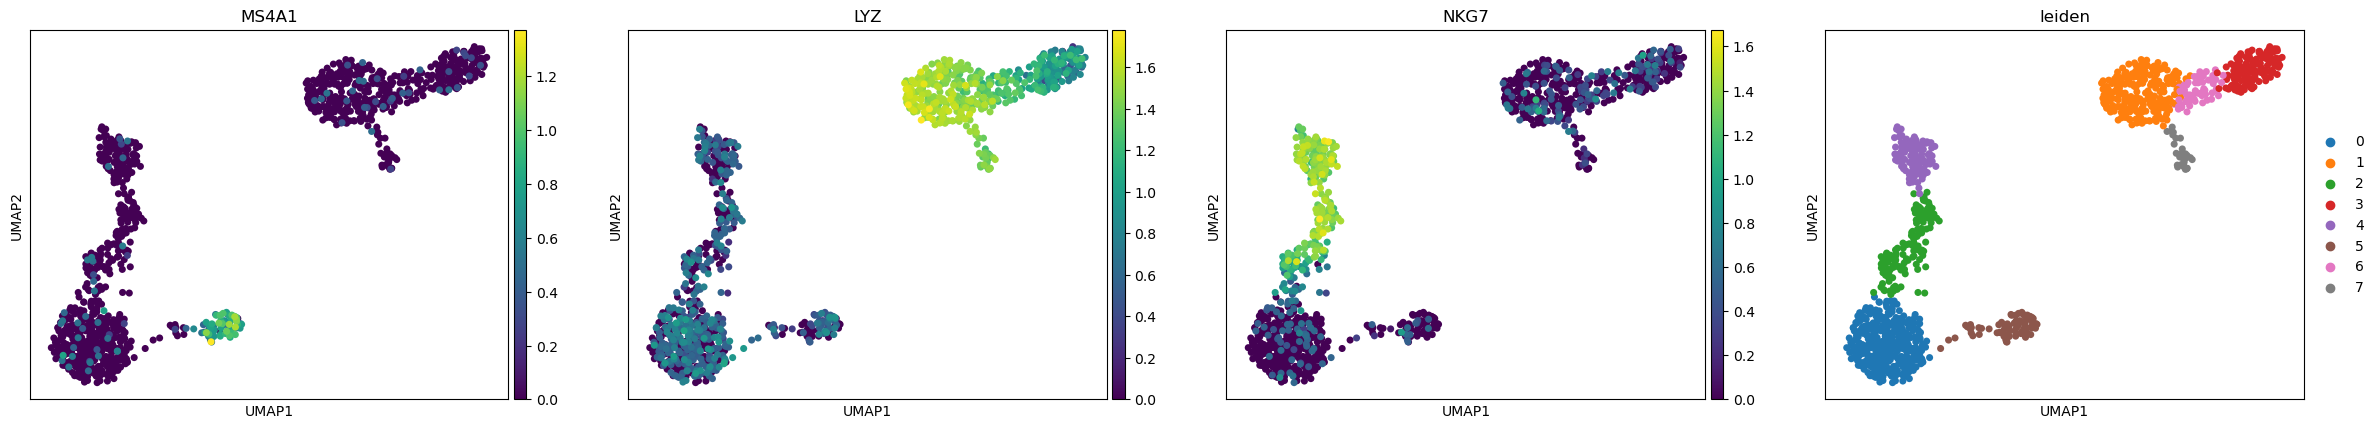

In [23]:
sc.pl.umap(
    adata,
    color=["MS4A1","LYZ","NKG7","leiden"]
)